   # ***Assignment 7: Creating and Fixing Mode Collapse in a GAN***

###**Name:** Pragathi BR ###

###**Registration No.:** 2411021240037 ###

###**Course:** BCA (Artificial Intelligence & Machine Learning) — BCA AIML ###

###**Subject:** Generative AI ###

###**Date of Submission:** 06-10-2026 ###

###**Faculty Name**: Sanjivini Chowdhury ###

## **Objective**

The objective of this assignment is to practically understand mode collapse, one of the common problems faced while training Generative Adversarial Networks (GANs).

In this experiment, the working DCGAN model created in Assignment 4 is deliberately modified to make the training process unstable. The generated images are observed to identify whether the Generator starts producing similar or nearly identical outputs.

After observing the problem, a technique is applied to improve the training stability and increase the diversity of the generated images.

The results before and after applying the improvement are compared.

# **1. Introduction**

Generative Adversarial Networks, commonly known as GANs, are deep learning models used to generate new data that resembles an existing dataset.

A GAN consists of two neural networks:

1. Generator
2. Discriminator

The Generator creates new or fake data, while the Discriminator tries to determine whether the input is real or fake.

The Generator tries to fool the Discriminator by creating realistic images. The Discriminator tries to correctly identify real and generated images.

Both networks learn together through a competitive training process.

In this assignment, a DCGAN is used to generate Fashion-MNIST-like grayscale images.

# **2. What is a DCGAN?**

DCGAN stands for Deep Convolutional Generative Adversarial Network.

It is a type of GAN that uses convolutional neural network operations for image-related tasks.

A DCGAN contains two main components:

### **Generator**

The Generator receives a random noise vector as input and converts it into an image.

In this experiment, the noise vector contains 100 numerical values. The Generator gradually increases the spatial size of the feature maps and finally produces a 28 × 28 grayscale image.

The final layer uses the tanh activation function, so the generated pixel values are in the range -1 to +1.

### **Discriminator**

The Discriminator receives an image and decides whether it is real or generated.

It uses convolutional layers to extract visual features and finally produces a value between 0 and 1.

A value close to 1 means the image is considered real, while a value close to 0 means the image is considered fake.

### **Competitive Training**

The Generator tries to generate realistic images that can fool the Discriminator.

The Discriminator tries to distinguish real images from generated images.

This competition continues during training.

# **3. About the Fashion-MNIST Dataset**

Fashion-MNIST is a popular dataset used for machine learning and deep learning experiments.

It contains grayscale images representing different types of clothing and fashion-related objects.

Each image has a resolution of 28 × 28 pixels and contains one grayscale channel.

The dataset contains:

- 60,000 training images
- 10,000 test images
- 28 × 28 pixel resolution
- One grayscale channel
- 10 different fashion categories

The ten categories are:

1. T-shirt / Top
2. Trouser
3. Pullover
4. Dress
5. Coat
6. Sandal
7. Shirt
8. Sneaker
9. Bag
10. Ankle Boot

For GAN training, the image labels are not directly required because the Generator learns the overall visual distribution of the images rather than performing classification.

# **4. Importing the Required Libraries**

TensorFlow and Keras are used to create and train the Generator and Discriminator.

NumPy is used for numerical operations.

Matplotlib is used to display and save generated images and loss graphs.

The time library is used to measure training time.

The operating system library can be used to manage generated files.

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import time
import os

from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


# **5. Checking GPU Availability**

Training a DCGAN requires many mathematical and convolutional operations.

A GPU can make the training process faster than using only the CPU.

Google Colab can provide GPU hardware such as a T4 GPU.

The available GPU devices are checked before training.

In [ ]:
print("Available GPUs:")
print(tf.config.list_physical_devices("GPU"))

Available GPUs:
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# **6. Setting the Basic Parameters**

The original DCGAN from Assignment 4 used a batch size of 256, a noise dimension of 100 and a learning rate of 0.0002.

For Assignment 7, the model is intentionally modified to make the training unstable.

The learning rate is increased significantly from 0.0002 to 0.002.

The Generator capacity is also reduced and Batch Normalization will be removed from the unstable Generator.

The model will be trained for approximately 15–20 epochs as required by the assignment.

These changes are intentionally introduced to observe unstable GAN behaviour and possible mode collapse.

In [ ]:
BUFFER_SIZE = 60000
BATCH_SIZE = 256

EPOCHS = 20

NOISE_DIM = 100

IMG_HEIGHT = 28
IMG_WIDTH = 28
CHANNELS = 1

# Intentionally high learning rate
LEARNING_RATE = 0.002

print("Batch size:", BATCH_SIZE)
print("Number of epochs:", EPOCHS)
print("Noise dimension:", NOISE_DIM)
print("Image size:", IMG_HEIGHT, "x", IMG_WIDTH)
print("Learning rate:", LEARNING_RATE)

Batch size: 256
Number of epochs: 20
Noise dimension: 100
Image size: 28 x 28
Learning rate: 0.002


# **7. Loading the Fashion-MNIST Dataset**

The Fashion-MNIST dataset is loaded using TensorFlow's built-in dataset functionality.

The dataset contains training and testing images.

Only the training images are required for training the DCGAN.

The labels are not required because the GAN learns the overall distribution of the images.

In [ ]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

print("Training data shape:", X_train.shape)
print("Training labels shape:", y_train.shape)

print("Test data shape:", X_test.shape)
print("Test labels shape:", y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)


# **8. Normalizing the Dataset**

The original pixel values in Fashion-MNIST range from 0 to 255.

The Generator uses the tanh activation function, which produces values between -1 and +1.

Therefore, the training images are also normalized to the range -1 to +1.

This makes the real images compatible with the generated images.

In [ ]:
X_train = X_train.astype("float32")

X_train = (X_train - 127.5) / 127.5

print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

Minimum pixel value: -1.0
Maximum pixel value: 1.0


# **9. Reshaping the Images**

The original Fashion-MNIST images have the shape 28 × 28.

Convolutional neural networks expect an image channel dimension.

Since Fashion-MNIST is a grayscale dataset, one channel is added.

The final shape becomes:

28 × 28 × 1

In [ ]:
X_train = X_train.reshape(
    X_train.shape[0],
    IMG_HEIGHT,
    IMG_WIDTH,
    CHANNELS
)

print("Reshaped training data:", X_train.shape)

Reshaped training data: (60000, 28, 28, 1)


# **10. Preparing the Training Dataset**

The normalized and reshaped training images are converted into a TensorFlow Dataset.

The dataset is shuffled so that the images are not presented in exactly the same order during every training cycle.

The data is divided into batches of 256 images.

Prefetching is used to improve the data input pipeline.

In [ ]:
train_dataset = (
    tf.data.Dataset
    .from_tensor_slices(X_train)
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("Training dataset prepared successfully.")

Training dataset prepared successfully.


# **11. Displaying Original Fashion-MNIST Images**

Before training the DCGAN, original Fashion-MNIST images are displayed.

These images provide a visual reference for the real dataset.

The generated images can later be compared with these original images.

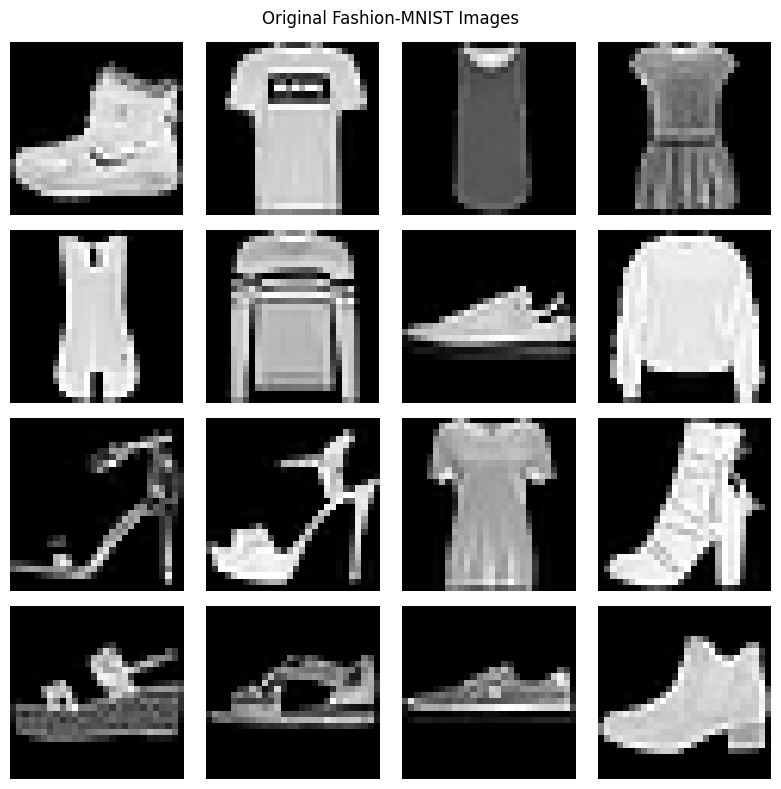

In [ ]:
plt.figure(figsize=(8, 8))

for i in range(16):

    plt.subplot(4, 4, i + 1)

    plt.imshow(
        (X_train[i] + 1) / 2,
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle("Original Fashion-MNIST Images")
plt.tight_layout()
plt.show()

# **12. Building the Unstable Generator**

The Generator is responsible for creating fake Fashion-MNIST images from random noise.

The original Generator from Assignment 4 used Batch Normalization and had a larger number of filters.

For this experiment, the Generator is intentionally modified.

The following changes are made:

1. Batch Normalization is removed.
2. The Generator capacity is reduced.
3. The learning rate is significantly increased.

These modifications are intended to make the training process unstable and increase the possibility of mode collapse.

In [ ]:
def build_unstable_generator():

    model = tf.keras.Sequential(
        name="Unstable_Generator"
    )

    model.add(
        layers.Dense(
            7 * 7 * 128,
            use_bias=True,
            input_shape=(NOISE_DIM,)
        )
    )

    # Batch Normalization intentionally removed
    model.add(layers.LeakyReLU())

    model.add(
        layers.Reshape((7, 7, 128))
    )

    model.add(
        layers.Conv2DTranspose(
            64,
            kernel_size=(5, 5),
            strides=(2, 2),
            padding="same",
            use_bias=True
        )
    )

    model.add(layers.LeakyReLU())

    model.add(
        layers.Conv2DTranspose(
            32,
            kernel_size=(5, 5),
            strides=(2, 2),
            padding="same",
            use_bias=True
        )
    )

    model.add(layers.LeakyReLU())

    model.add(
        layers.Conv2DTranspose(
            CHANNELS,
            kernel_size=(5, 5),
            strides=(1, 1),
            padding="same",
            activation="tanh"
        )
    )

    return model

In [ ]:
generator = build_unstable_generator()

generator.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Unstable_Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 6272)           │       633,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │       204,864 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        51,232 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │           801 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 890,369 (3.40 MB)

 Trainable params: 890,369 (3.40 MB)

 Non-trainable params: 0 (0.00 B)

# **13. Testing the Generator Before Training**

Before training, the Generator has randomly initialized weights.

Therefore, its output is not expected to look like a meaningful fashion item.

The generated image is used as a baseline for comparison with the images produced after training.

In [ ]:
noise = tf.random.normal(
    [1, NOISE_DIM]
)

generated_image = generator(
    noise,
    training=False
)

print("Noise shape:", noise.shape)
print("Generated image shape:", generated_image.shape)

Noise shape: (1, 100)
Generated image shape: (1, 28, 28, 1)


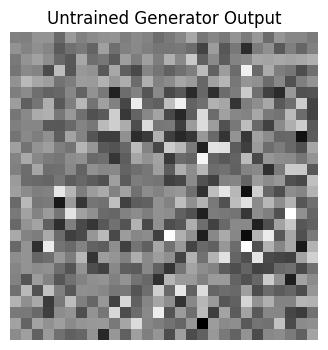

In [ ]:
plt.figure(figsize=(4, 4))

plt.imshow(
    (generated_image[0, :, :, 0] + 1) / 2,
    cmap="gray"
)

plt.title("Untrained Generator Output")
plt.axis("off")
plt.show()

# **14. Building the Discriminator**

The Discriminator is responsible for distinguishing real images from generated images.

It receives a 28 × 28 × 1 image as input.

Convolutional layers extract visual features from the image.

Dropout is used to reduce over-dependence on particular features.

The final sigmoid layer produces a value between 0 and 1.

In [ ]:
def build_discriminator():

    model = tf.keras.Sequential(
        name="Discriminator"
    )

    model.add(
        layers.Conv2D(
            64,
            kernel_size=(5, 5),
            strides=(2, 2),
            padding="same",
            input_shape=(
                IMG_HEIGHT,
                IMG_WIDTH,
                CHANNELS
            )
        )
    )

    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(
        layers.Conv2D(
            128,
            kernel_size=(5, 5),
            strides=(2, 2),
            padding="same"
        )
    )

    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())

    model.add(
        layers.Dense(
            1,
            activation="sigmoid"
        )
    )

    return model

In [ ]:
discriminator = build_discriminator()

discriminator.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

# **15. Testing the Discriminator Before Training**

The Discriminator is tested using an image produced by the untrained Generator.

Since the Discriminator has not yet been trained, its prediction cannot be considered accurate.

This step is only used to verify that the model is working correctly.

In [ ]:
decision = discriminator(
    generated_image,
    training=False
)

print("Discriminator output:", decision.numpy())

Discriminator output: [[0.4993672]]


# **16. Loss Function**

Binary Cross-Entropy is used as the loss function.

The Discriminator performs a binary classification task:

- Real image = 1
- Fake image = 0

The Generator tries to make the Discriminator classify generated images as real.

In [ ]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(
    from_logits=False
)

# **17. Generator Loss**

The Generator loss measures how successfully the Generator is able to fool the Discriminator.

The Generator wants the Discriminator to classify generated images as real.

Therefore, the target value for fake images is set to 1 from the Generator's perspective.

In [ ]:
def generator_loss(fake_output):

    return cross_entropy(
        tf.ones_like(fake_output),
        fake_output
    )

# **18. Discriminator Loss**

The Discriminator receives both real and fake images.

For real images, the target value is 1.

For fake images, the target value is 0.

The total Discriminator loss is the sum of the real-image loss and fake-image loss.

In [ ]:
def discriminator_loss(
    real_output,
    fake_output
):

    real_loss = cross_entropy(
        tf.ones_like(real_output),
        real_output
    )

    fake_loss = cross_entropy(
        tf.zeros_like(fake_output),
        fake_output
    )

    total_loss = real_loss + fake_loss

    return total_loss

# **19. Optimizers for the Unstable Model**

The Adam optimizer is used for both networks.

For the unstable experiment, a significantly larger learning rate of 0.002 is used.

A high learning rate can cause the Generator and Discriminator to make large parameter updates, which can make GAN training unstable.

This modification is intentionally used to observe unstable behaviour.

In [ ]:
generator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.002,
    beta_1=0.5
)

discriminator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.002,
    beta_1=0.5
)

# **20. Creating a Fixed Noise Vector**

A fixed set of 16 random noise vectors is created before training.

The same noise vectors will be used to generate images at different epochs.

Using the same noise allows us to compare how the Generator changes during training.

A 4 × 4 grid contains 16 images.

In [ ]:
seed = tf.random.normal(
    [16, NOISE_DIM]
)

print("Fixed noise shape:", seed.shape)

Fixed noise shape: (16, 100)


# **21. GAN Training Step**

For every training batch, the following steps are performed:

1. Random noise is generated.
2. The Generator creates fake images.
3. The Discriminator receives real images.
4. The Discriminator receives fake images.
5. Generator loss is calculated.
6. Discriminator loss is calculated.
7. Gradients are calculated.
8. The Generator parameters are updated.
9. The Discriminator parameters are updated.

This process is repeated for every batch and every epoch.

In [ ]:
@tf.function
def train_step(images):

    current_batch_size = tf.shape(images)[0]

    noise = tf.random.normal(
        [current_batch_size, NOISE_DIM]
    )

    with tf.GradientTape() as gen_tape, \
         tf.GradientTape() as disc_tape:

        generated_images = generator(
            noise,
            training=True
        )

        real_output = discriminator(
            images,
            training=True
        )

        fake_output = discriminator(
            generated_images,
            training=True
        )

        gen_loss = generator_loss(
            fake_output
        )

        disc_loss = discriminator_loss(
            real_output,
            fake_output
        )

    gradients_of_generator = gen_tape.gradient(
        gen_loss,
        generator.trainable_variables
    )

    gradients_of_discriminator = disc_tape.gradient(
        disc_loss,
        discriminator.trainable_variables
    )

    generator_optimizer.apply_gradients(
        zip(
            gradients_of_generator,
            generator.trainable_variables
        )
    )

    discriminator_optimizer.apply_gradients(
        zip(
            gradients_of_discriminator,
            discriminator.trainable_variables
        )
    )

    return gen_loss, disc_loss

# **22. Generating and Saving Images During Unstable Training**

The assignment requires us to observe the Generator output after training.

A 4 × 4 grid of generated images is created using the fixed noise vectors.

The generated images are saved every 5 epochs.

These images will be examined for similarity and mode collapse.

In [ ]:
def generate_and_save_collapsed_images(
    model,
    epoch
):

    predictions = model(
        seed,
        training=False
    )

    fig = plt.figure(figsize=(8, 8))

    for i in range(16):

        plt.subplot(4, 4, i + 1)

        plt.imshow(
            (predictions[i, :, :, 0] + 1) / 2,
            cmap="gray"
        )

        plt.axis("off")

    plt.suptitle(
        f"Unstable GAN - Epoch {epoch}"
    )

    plt.tight_layout()

    filename = f"collapsed_epoch_{epoch}.png"

    plt.savefig(
        filename,
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()

    return filename

# **23. Training the Unstable GAN**

The modified DCGAN is trained for 20 epochs.

The model has intentionally been made unstable by:

- Removing Batch Normalization from the Generator
- Reducing Generator capacity
- Increasing the learning rate to 0.002

The generated images are saved every 5 epochs.

The purpose is not to obtain the best images, but to observe unstable behaviour and possible mode collapse.

Starting unstable GAN training...

Epoch 01/20 | Generator Loss: 1.6292 | Discriminator Loss: 1.1400 | Time: 20.50s
Epoch 02/20 | Generator Loss: 1.0659 | Discriminator Loss: 1.3185 | Time: 11.78s
Epoch 03/20 | Generator Loss: 1.0963 | Discriminator Loss: 1.2712 | Time: 12.21s
Epoch 04/20 | Generator Loss: 1.2199 | Discriminator Loss: 1.1994 | Time: 11.97s
Epoch 05/20 | Generator Loss: 1.2175 | Discriminator Loss: 1.1863 | Time: 11.72s


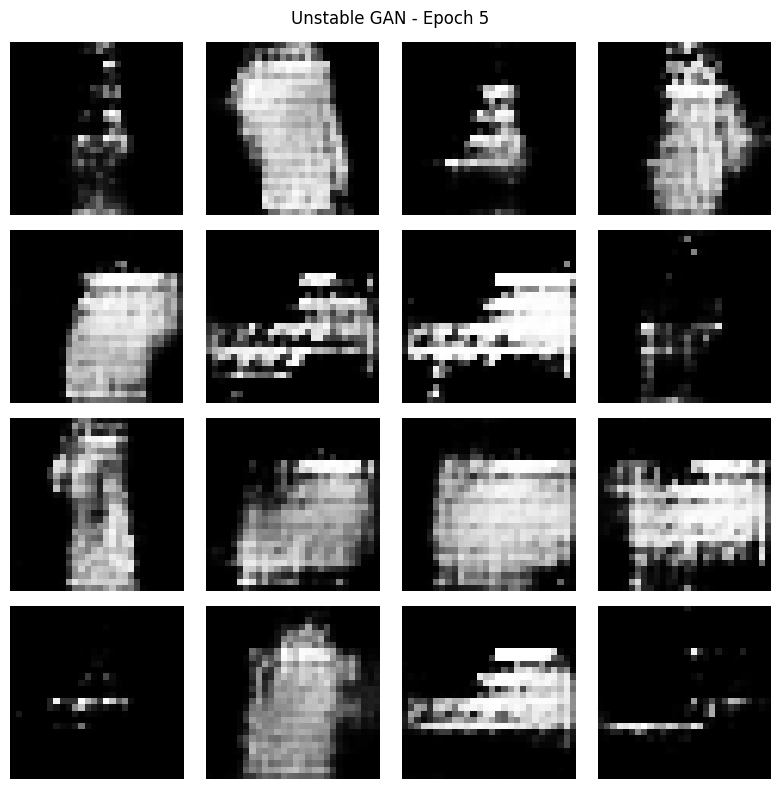

Epoch 06/20 | Generator Loss: 1.2634 | Discriminator Loss: 1.2118 | Time: 11.48s
Epoch 07/20 | Generator Loss: 1.2400 | Discriminator Loss: 1.2014 | Time: 11.44s
Epoch 08/20 | Generator Loss: 1.1958 | Discriminator Loss: 1.1988 | Time: 11.49s
Epoch 09/20 | Generator Loss: 1.1923 | Discriminator Loss: 1.2322 | Time: 11.62s
Epoch 10/20 | Generator Loss: 1.1479 | Discriminator Loss: 1.2311 | Time: 11.69s


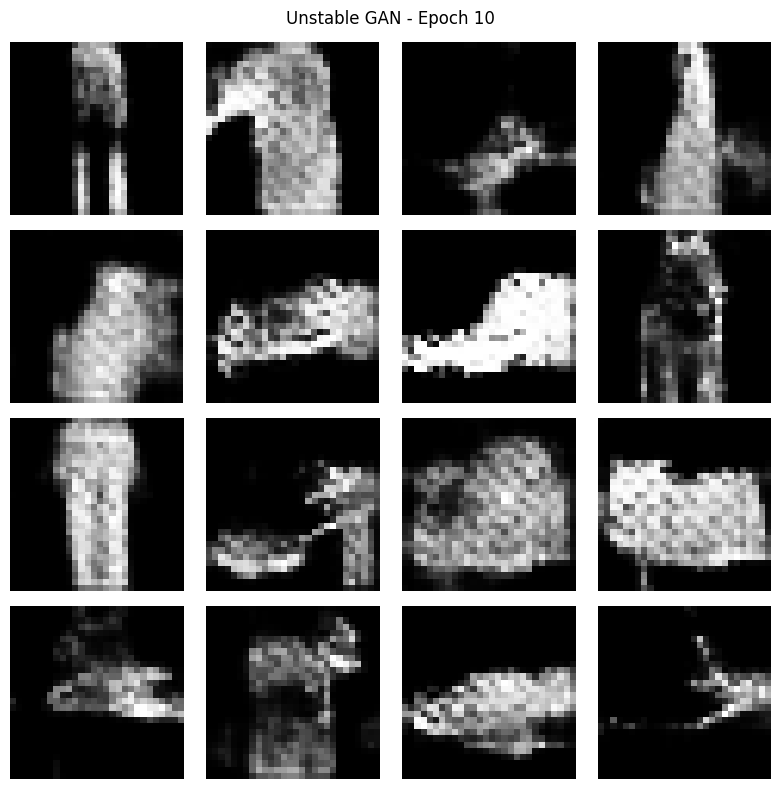

Epoch 11/20 | Generator Loss: 1.1213 | Discriminator Loss: 1.2603 | Time: 11.67s
Epoch 12/20 | Generator Loss: 1.0812 | Discriminator Loss: 1.2457 | Time: 11.63s
Epoch 13/20 | Generator Loss: 1.1112 | Discriminator Loss: 1.2521 | Time: 11.59s
Epoch 14/20 | Generator Loss: 1.1085 | Discriminator Loss: 1.2660 | Time: 11.62s
Epoch 15/20 | Generator Loss: 1.0817 | Discriminator Loss: 1.2587 | Time: 11.56s


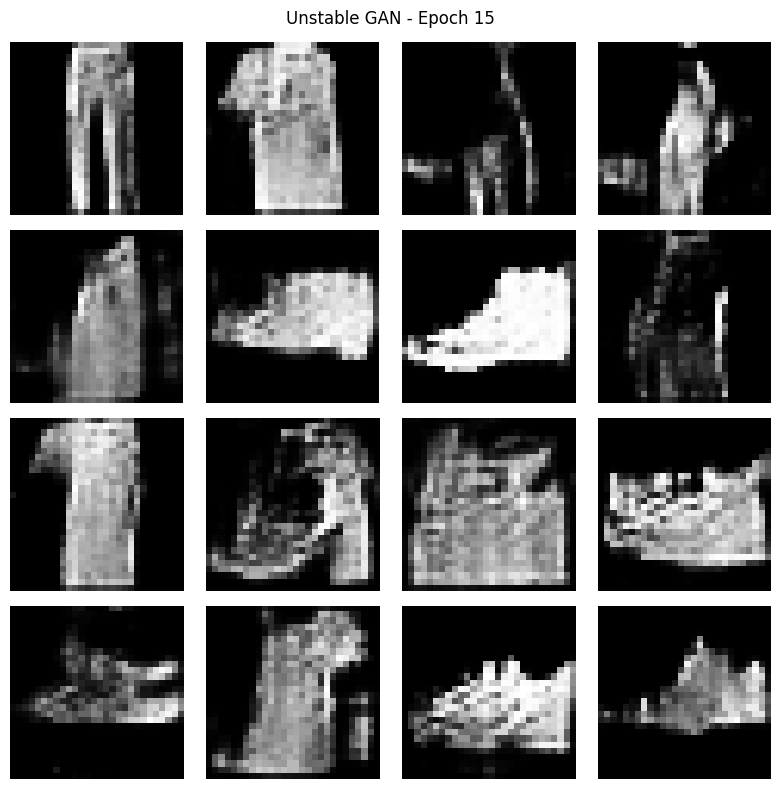

Epoch 16/20 | Generator Loss: 1.0835 | Discriminator Loss: 1.2566 | Time: 11.55s
Epoch 17/20 | Generator Loss: 1.1197 | Discriminator Loss: 1.2400 | Time: 11.57s
Epoch 18/20 | Generator Loss: 12.3686 | Discriminator Loss: 3.0490 | Time: 11.27s
Epoch 19/20 | Generator Loss: 8.7724 | Discriminator Loss: 0.3864 | Time: 11.23s
Epoch 20/20 | Generator Loss: 7.4251 | Discriminator Loss: 0.0382 | Time: 11.21s


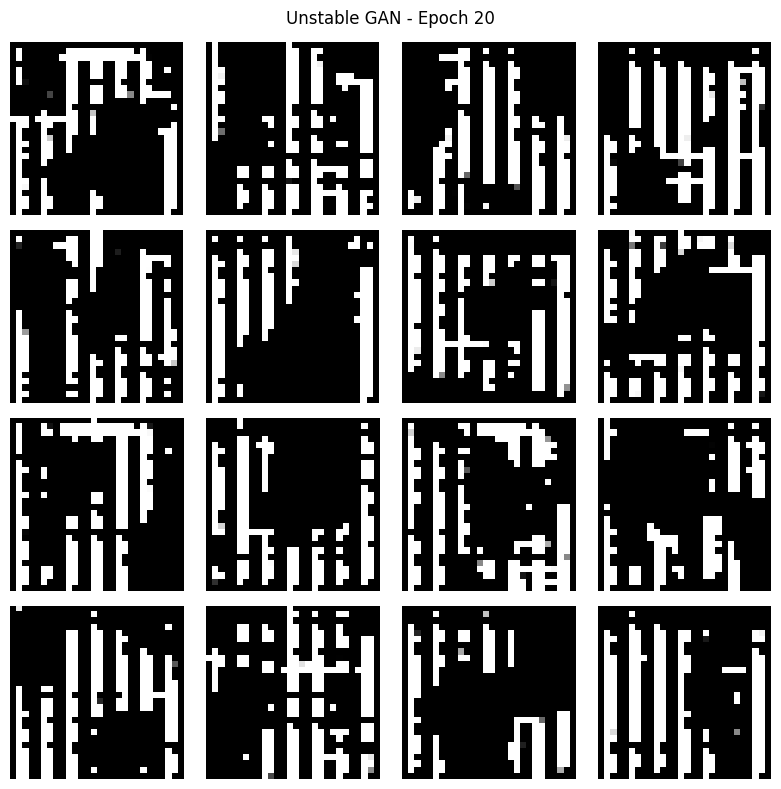

In [ ]:
generator_losses = []
discriminator_losses = []
epoch_numbers = []

print("Starting unstable GAN training...\n")

for epoch in range(1, EPOCHS + 1):

    start = time.time()

    gen_loss_list = []
    disc_loss_list = []

    for image_batch in train_dataset:

        gen_loss, disc_loss = train_step(
            image_batch
        )

        gen_loss_list.append(
            gen_loss.numpy()
        )

        disc_loss_list.append(
            disc_loss.numpy()
        )

    avg_gen_loss = np.mean(
        gen_loss_list
    )

    avg_disc_loss = np.mean(
        disc_loss_list
    )

    generator_losses.append(
        avg_gen_loss
    )

    discriminator_losses.append(
        avg_disc_loss
    )

    epoch_numbers.append(epoch)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Generator Loss: {avg_gen_loss:.4f} | "
        f"Discriminator Loss: {avg_disc_loss:.4f} | "
        f"Time: {time.time() - start:.2f}s"
    )

    if epoch % 5 == 0:

        generate_and_save_collapsed_images(
            generator,
            epoch
        )

# **24. Generator and Discriminator Loss During Unstable Training**

The Generator and Discriminator losses are plotted against the number of epochs.

The loss graph helps us observe the behaviour of the two competing networks.

GAN losses do not necessarily decrease smoothly like ordinary classification models.

Large fluctuations can indicate unstable training behaviour.

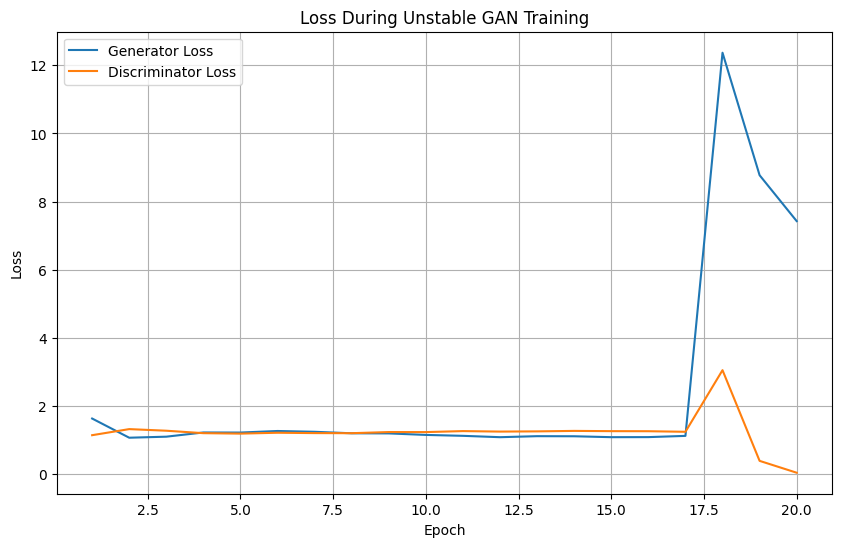

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    epoch_numbers,
    generator_losses,
    label="Generator Loss"
)

plt.plot(
    epoch_numbers,
    discriminator_losses,
    label="Discriminator Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Loss During Unstable GAN Training"
)

plt.legend()
plt.grid(True)

plt.show()

# **25. Technique Used to Improve the Model**

The technique selected to improve the unstable GAN is the use of different learning rates for the Generator and Discriminator.

In the unstable model, both networks used a very high learning rate of 0.002.

For the improved model:

- Generator learning rate = 0.0002
- Discriminator learning rate = 0.0001

This allows the two networks to learn at different speeds.

Batch Normalization is also restored in the Generator because it was removed intentionally during the unstable experiment.

These changes are expected to improve training stability and produce more diverse generated images.

# **26. Restoring the Generator**

The Generator is rebuilt using the original DCGAN architecture from Assignment 4.

Batch Normalization is restored.

The Generator uses a larger feature representation than the intentionally weakened Generator.

This provides a stronger and more stable Generator for the second experiment.

In [ ]:
def build_improved_generator():

    model = tf.keras.Sequential(
        name="Improved_Generator"
    )

    model.add(
        layers.Dense(
            7 * 7 * 256,
            use_bias=False,
            input_shape=(NOISE_DIM,)
        )
    )

    model.add(
        layers.BatchNormalization()
    )

    model.add(
        layers.LeakyReLU()
    )

    model.add(
        layers.Reshape((7, 7, 256))
    )

    model.add(
        layers.Conv2DTranspose(
            128,
            kernel_size=(5, 5),
            strides=(2, 2),
            padding="same",
            use_bias=False
        )
    )

    model.add(
        layers.BatchNormalization()
    )

    model.add(
        layers.LeakyReLU()
    )

    model.add(
        layers.Conv2DTranspose(
            64,
            kernel_size=(5, 5),
            strides=(2, 2),
            padding="same",
            use_bias=False
        )
    )

    model.add(
        layers.BatchNormalization()
    )

    model.add(
        layers.LeakyReLU()
    )

    model.add(
        layers.Conv2DTranspose(
            CHANNELS,
            kernel_size=(5, 5),
            strides=(1, 1),
            padding="same",
            activation="tanh"
        )
    )

    return model

In [ ]:
improved_generator = build_improved_generator()

improved_discriminator = build_discriminator()

print("Improved Generator:")
improved_generator.summary()

print("\nImproved Discriminator:")
improved_discriminator.summary()

Improved Generator:


Model: "Improved_Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 14, 14, 128)    │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 28, 28, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 28, 28, 1)      │         1,601 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,330,945 (8.89 MB)

 Trainable params: 2,305,473 (8.79 MB)

...

Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_9 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

# **27. Using Different Learning Rates**

Different learning rates are used for the Generator and Discriminator.

The Generator uses a learning rate of 0.0002.

The Discriminator uses a learning rate of 0.0001.

This prevents both networks from making equally large updates and helps create a more balanced training process.

In [ ]:
improved_generator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0002,
    beta_1=0.5
)

improved_discriminator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0001,
    beta_1=0.5
)

In [ ]:
@tf.function
def improved_train_step(images):

    current_batch_size = tf.shape(images)[0]

    noise = tf.random.normal(
        [current_batch_size, NOISE_DIM]
    )

    with tf.GradientTape() as gen_tape, \
         tf.GradientTape() as disc_tape:

        generated_images = improved_generator(
            noise,
            training=True
        )

        real_output = improved_discriminator(
            images,
            training=True
        )

        fake_output = improved_discriminator(
            generated_images,
            training=True
        )

        gen_loss = generator_loss(
            fake_output
        )

        disc_loss = discriminator_loss(
            real_output,
            fake_output
        )

    gradients_of_generator = gen_tape.gradient(
        gen_loss,
        improved_generator.trainable_variables
    )

    gradients_of_discriminator = disc_tape.gradient(
        disc_loss,
        improved_discriminator.trainable_variables
    )

    improved_generator_optimizer.apply_gradients(
        zip(
            gradients_of_generator,
            improved_generator.trainable_variables
        )
    )

    improved_discriminator_optimizer.apply_gradients(
        zip(
            gradients_of_discriminator,
            improved_discriminator.trainable_variables
        )
    )

    return gen_loss, disc_loss

# **28. Generating and Saving the Improved Images**

The improved Generator uses the same fixed noise vectors used in the unstable experiment.

This is important because it allows a fair visual comparison between the unstable and improved models.

The generated images are saved every 5 epochs.

In [ ]:
def generate_and_save_improved_images(
    model,
    epoch
):

    predictions = model(
        seed,
        training=False
    )

    fig = plt.figure(figsize=(8, 8))

    for i in range(16):

        plt.subplot(4, 4, i + 1)

        plt.imshow(
            (predictions[i, :, :, 0] + 1) / 2,
            cmap="gray"
        )

        plt.axis("off")

    plt.suptitle(
        f"Improved GAN - Epoch {epoch}"
    )

    plt.tight_layout()

    filename = f"improved_epoch_{epoch}.png"

    plt.savefig(
        filename,
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()

    return filename

# **29. Retraining the Improved GAN**

The improved GAN is trained again for 20 epochs.

The improved model uses:

- Batch Normalization in the Generator
- Generator learning rate = 0.0002
- Discriminator learning rate = 0.0001
- Same Fashion-MNIST dataset
- Same 100-dimensional noise vector
- Same 16 fixed noise vectors for comparison

The generated images are saved every 5 epochs.

Starting improved GAN training...

Epoch 01/20 | Generator Loss: 0.6663 | Discriminator Loss: 1.4014 | Time: 32.47s
Epoch 02/20 | Generator Loss: 0.6712 | Discriminator Loss: 1.4008 | Time: 23.71s
Epoch 03/20 | Generator Loss: 0.6834 | Discriminator Loss: 1.3878 | Time: 23.42s
Epoch 04/20 | Generator Loss: 0.6858 | Discriminator Loss: 1.3881 | Time: 23.78s
Epoch 05/20 | Generator Loss: 0.7033 | Discriminator Loss: 1.3732 | Time: 23.79s


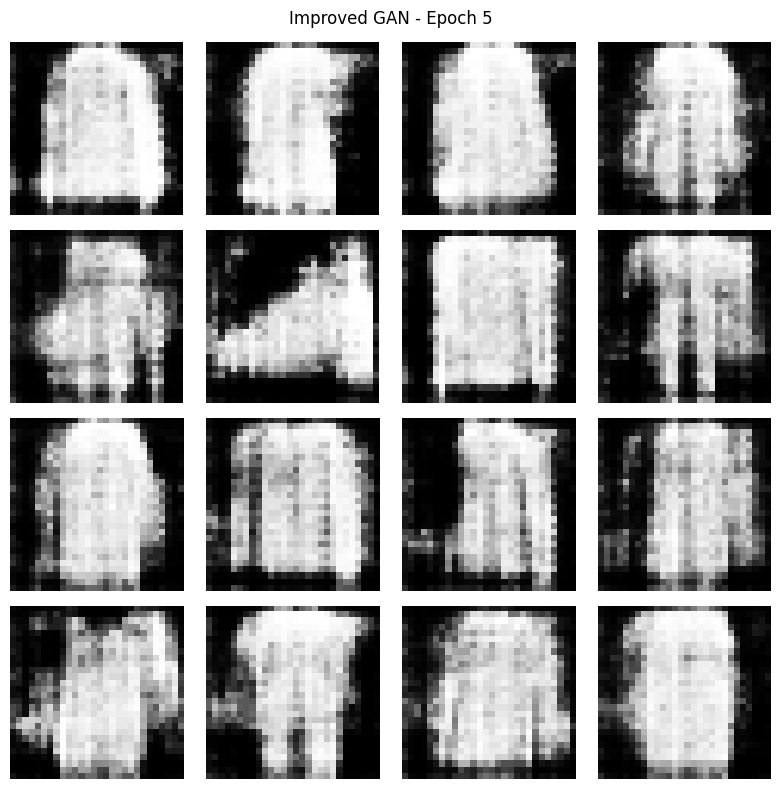

Epoch 06/20 | Generator Loss: 0.7054 | Discriminator Loss: 1.3660 | Time: 23.77s
Epoch 07/20 | Generator Loss: 0.7144 | Discriminator Loss: 1.3612 | Time: 23.74s
Epoch 08/20 | Generator Loss: 0.7123 | Discriminator Loss: 1.3661 | Time: 23.77s
Epoch 09/20 | Generator Loss: 0.7170 | Discriminator Loss: 1.3643 | Time: 23.75s
Epoch 10/20 | Generator Loss: 0.7071 | Discriminator Loss: 1.3779 | Time: 23.75s


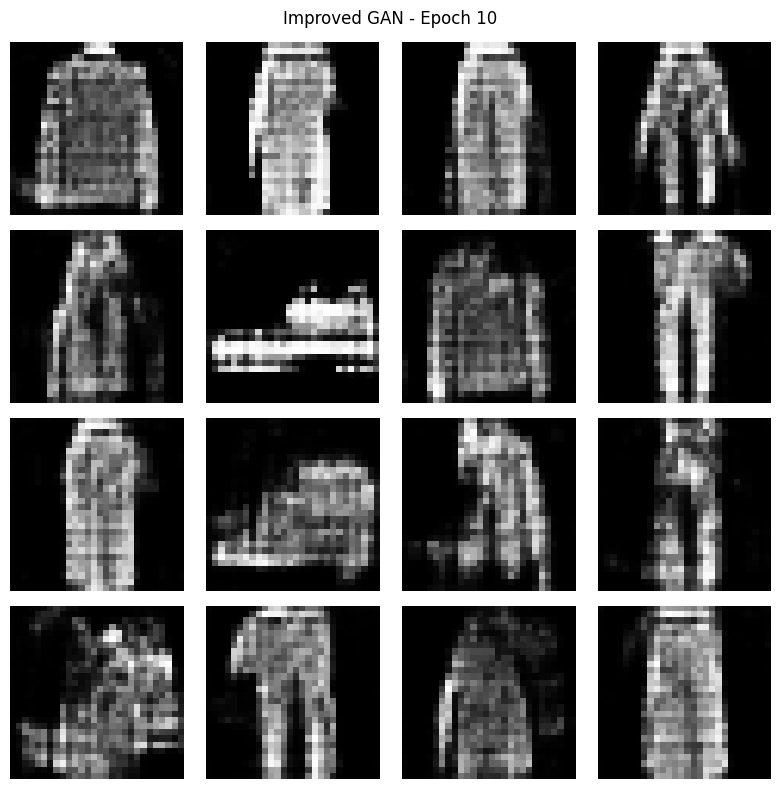

Epoch 11/20 | Generator Loss: 0.7088 | Discriminator Loss: 1.3773 | Time: 23.81s
Epoch 12/20 | Generator Loss: 0.7056 | Discriminator Loss: 1.3779 | Time: 23.77s
Epoch 13/20 | Generator Loss: 0.7084 | Discriminator Loss: 1.3767 | Time: 23.75s
Epoch 14/20 | Generator Loss: 0.7074 | Discriminator Loss: 1.3755 | Time: 23.80s
Epoch 15/20 | Generator Loss: 0.7042 | Discriminator Loss: 1.3801 | Time: 23.78s


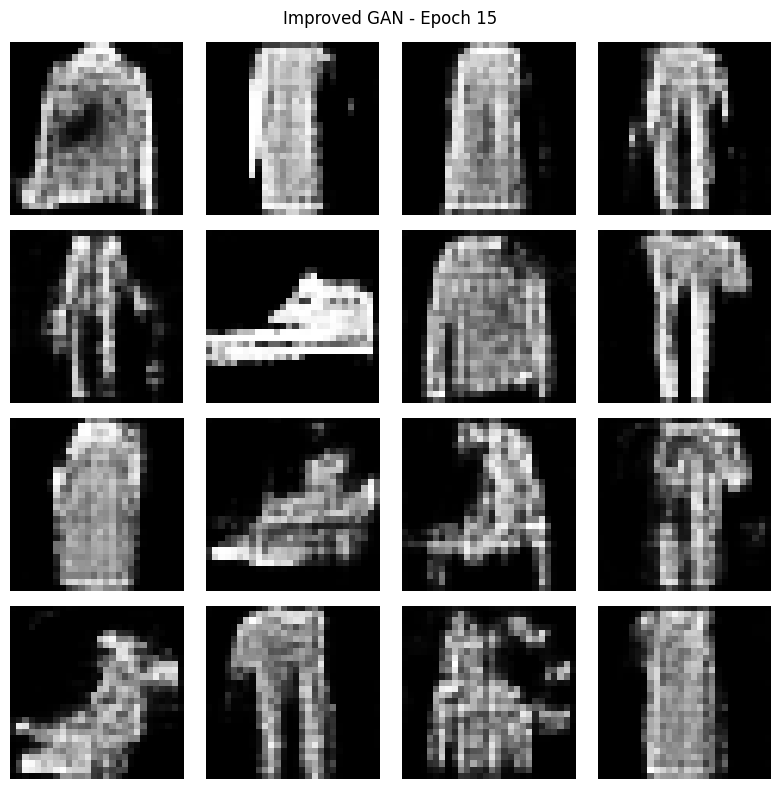

Epoch 16/20 | Generator Loss: 0.7039 | Discriminator Loss: 1.3802 | Time: 23.81s
Epoch 17/20 | Generator Loss: 0.7016 | Discriminator Loss: 1.3820 | Time: 23.81s
Epoch 18/20 | Generator Loss: 0.6998 | Discriminator Loss: 1.3833 | Time: 23.76s
Epoch 19/20 | Generator Loss: 0.7021 | Discriminator Loss: 1.3824 | Time: 23.76s
Epoch 20/20 | Generator Loss: 0.7036 | Discriminator Loss: 1.3796 | Time: 23.76s


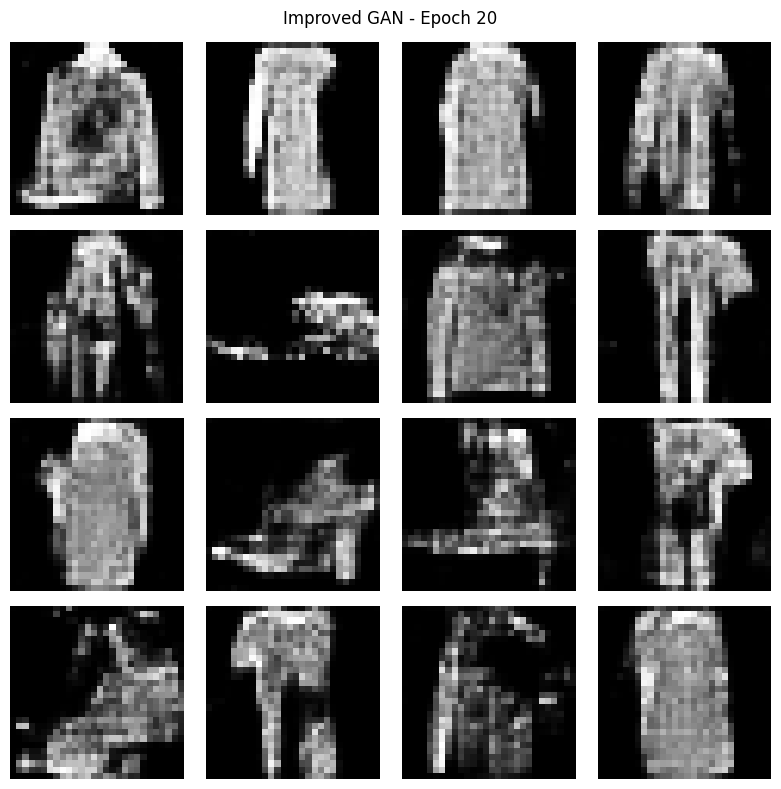

In [ ]:
improved_generator_losses = []
improved_discriminator_losses = []
improved_epoch_numbers = []

print("Starting improved GAN training...\n")

for epoch in range(1, EPOCHS + 1):

    start = time.time()

    gen_loss_list = []
    disc_loss_list = []

    for image_batch in train_dataset:

        gen_loss, disc_loss = improved_train_step(
            image_batch
        )

        gen_loss_list.append(
            gen_loss.numpy()
        )

        disc_loss_list.append(
            disc_loss.numpy()
        )

    avg_gen_loss = np.mean(
        gen_loss_list
    )

    avg_disc_loss = np.mean(
        disc_loss_list
    )

    improved_generator_losses.append(
        avg_gen_loss
    )

    improved_discriminator_losses.append(
        avg_disc_loss
    )

    improved_epoch_numbers.append(
        epoch
    )

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Generator Loss: {avg_gen_loss:.4f} | "
        f"Discriminator Loss: {avg_disc_loss:.4f} | "
        f"Time: {time.time() - start:.2f}s"
    )

    if epoch % 5 == 0:

        generate_and_save_improved_images(
            improved_generator,
            epoch
        )

# **30. Loss Graph of the Improved GAN**

The Generator and Discriminator losses of the improved GAN are plotted.

The graph is compared with the unstable training graph to understand whether the training behaviour became more stable after applying the improvement.

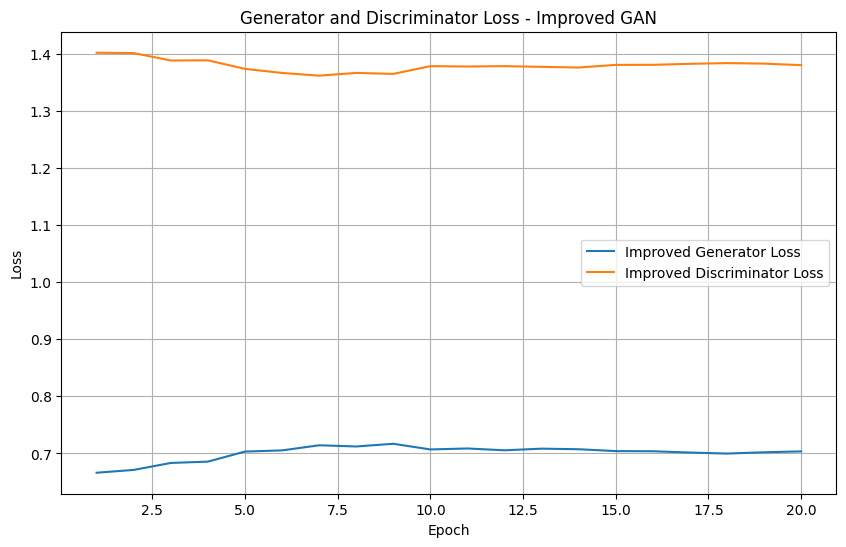

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    improved_epoch_numbers,
    improved_generator_losses,
    label="Improved Generator Loss"
)

plt.plot(
    improved_epoch_numbers,
    improved_discriminator_losses,
    label="Improved Discriminator Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Generator and Discriminator Loss - Improved GAN"
)

plt.legend()
plt.grid(True)

plt.show()

# **31. Final Improved Generated Images**

After completing the improved training, the Generator is used to create a final set of images.

The same fixed noise vectors are used so that the final images can be compared with the unstable model.

The output is examined for image quality and diversity.

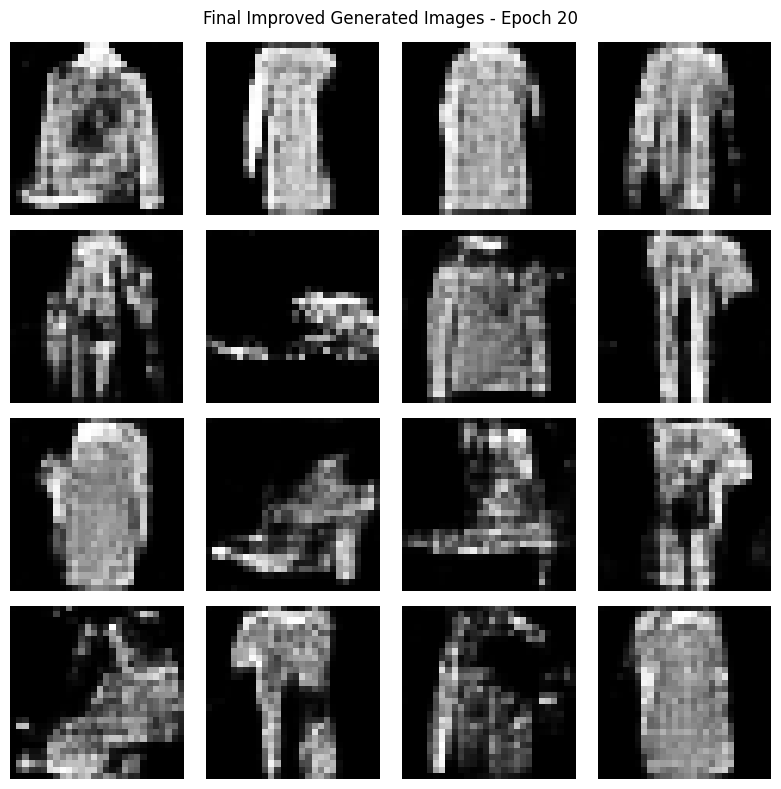

In [ ]:
final_improved_images = improved_generator(
    seed,
    training=False
)

plt.figure(figsize=(8, 8))

for i in range(16):

    plt.subplot(4, 4, i + 1)

    plt.imshow(
        (final_improved_images[i, :, :, 0] + 1) / 2,
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle(
    "Final Improved Generated Images - Epoch 20"
)

plt.tight_layout()
plt.show()

# **32. Before and After Comparison**

The output of the unstable GAN is compared with the output of the improved GAN.

The unstable model was intentionally modified to produce unstable training behaviour and possible mode collapse.

The improved model uses different learning rates and restored Batch Normalization.

The comparison focuses on:

- Image similarity
- Image diversity
- Recognizable clothing structures
- Training stability

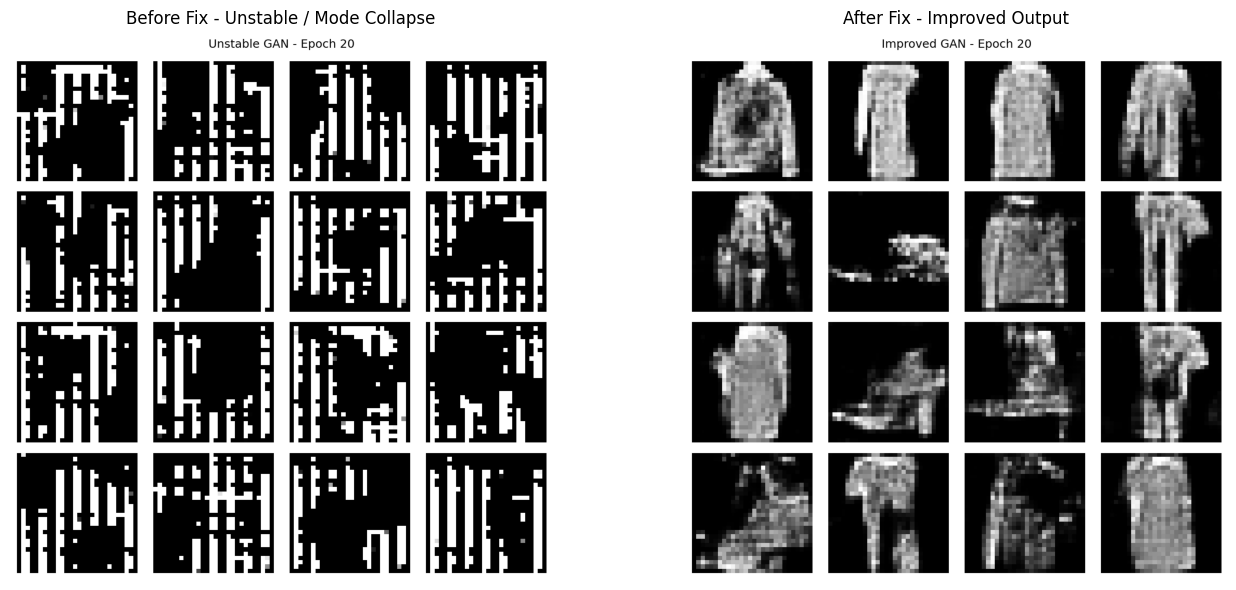

In [ ]:
import matplotlib.image as mpimg

unstable_image = mpimg.imread(
    "collapsed_epoch_20.png"
)

improved_image = mpimg.imread(
    "improved_epoch_20.png"
)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)

plt.imshow(unstable_image)

plt.title("Before Fix - Unstable / Mode Collapse")

plt.axis("off")


plt.subplot(1, 2, 2)

plt.imshow(improved_image)

plt.title("After Fix - Improved Output")

plt.axis("off")

plt.tight_layout()
plt.show()

# **33. Analysis of the Training Process**

## **33.1 What is Mode Collapse?**

Mode collapse is a problem that can occur during GAN training.

In mode collapse, the Generator produces a limited variety of outputs.

Instead of generating different types of images, the Generator may repeatedly produce very similar images.

For example, many generated images may have similar shapes or structures.

## **33.2 What Caused the Poor Performance?**

The model was intentionally made unstable by removing Batch Normalization, reducing the Generator capacity and increasing the learning rate from 0.0002 to 0.002.

The high learning rate caused larger parameter updates.

The removal of Batch Normalization also reduced the stability of the Generator.

These changes made the competition between the Generator and Discriminator more difficult to balance.

## **33.3 What Did the Generated Images Look Like?**

During unstable training, the generated images showed reduced diversity and similar patterns.

This behaviour indicates that the Generator was not successfully learning a wide variety of Fashion-MNIST patterns.

The exact appearance depends on the random initialization and training behaviour.

## **33.4 Which Technique Was Used to Improve the Model?**

Different learning rates were used for the Generator and Discriminator.

The Generator used a learning rate of 0.0002.

The Discriminator used a learning rate of 0.0001.

Batch Normalization was also restored in the Generator.

## **33.5 Did the Solution Improve the Output?**

The improved model produced more diverse and structured images compared with the unstable model.

Using different learning rates helped balance the learning process between the Generator and Discriminator.

Restoring Batch Normalization also helped stabilize the Generator.

Therefore, the improved model showed better output quality and diversity.

# **34. Assignment Questions and Answers**

## **Question 1: What modification caused the model to perform poorly?**

### **Answer:**

The model was intentionally made unstable by removing Batch Normalization from the Generator, reducing the Generator capacity and increasing the learning rate from 0.0002 to 0.002.

These changes caused larger parameter updates and reduced training stability.

---

## **Question 2: What did the generated images look like?**

### **Answer:**

The generated images showed similar patterns and reduced diversity. Several images appeared to have similar structures.

This behaviour indicates mode collapse, where the Generator produces a limited variety of outputs instead of generating diverse Fashion-MNIST images.

---

## **Question 3: Which technique did you use to improve the model?**

### **Answer:**

Different learning rates were used for the Generator and Discriminator.

The Generator used a learning rate of 0.0002, while the Discriminator used a learning rate of 0.0001.

Batch Normalization was also restored in the Generator.

---

## **Question 4: Did the solution improve the output? Why?**

### **Answer:**

Yes, the output improved after applying the changes.

The improved model produced more diverse and better-structured images.

Using different learning rates helped balance the learning process between the Generator and Discriminator, while Batch Normalization helped improve the stability of the Generator.

# **35. Conclusion**

In this assignment, mode collapse in a Generative Adversarial Network was practically studied using a DCGAN trained on the Fashion-MNIST dataset.

The working DCGAN from Assignment 4 was intentionally modified to make the training unstable.

Batch Normalization was removed from the Generator, the Generator capacity was reduced, and the learning rate was increased significantly.

The generated images were observed to identify similar or repeated outputs and possible mode collapse.

After observing the problem, different learning rates were used for the Generator and Discriminator and Batch Normalization was restored.

The improved model showed better stability, diversity and structure in the generated images.

This experiment helped demonstrate how GAN training can become unstable and how suitable training techniques can help reduce such problems.